In [30]:
import numpy as np
import gymnasium as gym
from typing import Optional
import copy
import gym
import numpy as np

class SchedulerEnv(gym.Env):

    def __init__(
        self,
        gender: int = 1,
        age: int = 25,
        height: float = 175.0,
        weight: float = 70.0,
        target_body_fat: float = 15.0,
        days_per_episode: int = 30,
        workloads: float = 1.5,
        sleep_duration: int = 8
    ):
        super().__init__()

        self.gender = gender
        self.age = age
        self.height = height
        self.weight = weight
        self.target_body_fat = target_body_fat
        self.days_per_episode = days_per_episode
        self.workloads = workloads
        self.sleep_duration = sleep_duration

        self.hours_per_day = 24
        self.scheduler = ["action"] * self.hours_per_day

        self.daily_meal_target = {
            "fiber": 34, #g
            "fat": 0.26, #ratio
            "carbs": 0.56, #ratio
            "protein": 0.18, #ratio
        }

        self.daily_total_targets = {
            "water": 3.7, #l
            "calcium": 1000, #mg
            "iron": 8, #mg
            "vitamin_c": 90 #mg
        }


        # ====== FIXED INDENTATION ======
        wake_up_hour = 6
        sleep_start = (wake_up_hour - self.sleep_duration) % 24

        if sleep_start < wake_up_hour:
            for i in range(sleep_start, wake_up_hour):
                self.scheduler[i] = 'sleep'
        else:
            for i in range(sleep_start, 24):
                self.scheduler[i] = 'sleep'
            for i in range(0, wake_up_hour):
                self.scheduler[i] = 'sleep'

        for start, end in [(10, 12), (13, 18)]:
            for i in range(start, end):
                self.scheduler[i] = 'work'

        walk_start = 8
        walk_duration = 1
        walk_end = (walk_start + walk_duration) % 24
        for i in range(walk_start, walk_end):
            self.scheduler[i] = 'walk'

        # ====== State definition ======
        self.state = {
            "current_weight": self.weight,
            "current_bmi": self.weight / (self.height / 100) ** 2,
            "current_body_fat": 1.2 * (self.weight / (self.height / 100) ** 2)
                                + 0.23 * self.age
                                - 10.8 * self.gender
                                - 5.4,
            "current_hours": 0,
            "day_of_episode": 0,
            "time_since_last_meal": 0,
            "time_since_last_exercise": 0,
            "body_fat_history": [],
            "daily_calories_burned": 0.0,
            "daily_calories_intake": 0.0,
            "daily_calories": self.weight * 24,
            "daily_fiber_intake": 0.0,
            "daily_fat_intake": 0.0,
            "daily_carbs_intake": 0.0,
            "daily_protein_intake": 0.0,
            "daily_water_intake": 0.0,
            "daily_calcium_intake": 0.0,
            "daily_iron_intake": 0.0,
            "daily_vitamin_c_intake": 0.0
        }

        # ====== Spaces ======
        self.action_space = gym.spaces.Discrete(10)
        self.observation_space = gym.spaces.Dict({
            "current_weight": gym.spaces.Box(low=30.0, high=300.0, shape=(1,), dtype=np.float32),
            "current_bmi": gym.spaces.Box(low=15.0, high=50.0, shape=(1,), dtype=np.float32),
            "current_body_fat": gym.spaces.Box(low=5.0, high=50.0, shape=(1,), dtype=np.float32),
            "current_hours": gym.spaces.Discrete(self.hours_per_day),
            "day_of_episode": gym.spaces.Box(low=0, high=self.days_per_episode, shape=(1,), dtype=np.int32),
            "time_since_last_meal": gym.spaces.Box(low=0, high=24, shape=(1,), dtype=np.int32),
            "time_since_last_exercise": gym.spaces.Box(low=0, high=self.days_per_episode * 24, shape=(1,), dtype=np.int32),
            "daily_calories_burned": gym.spaces.Box(low=0.0, high=4000.0, shape=(1,), dtype=np.float32),
            "daily_calories_intake": gym.spaces.Box(low=0.0, high=4000.0, shape=(1,), dtype=np.float32),
            "daily_calories": gym.spaces.Box(low=500.0, high=3000.0, shape=(1,), dtype=np.float32),
            "daily_fiber_intake": gym.spaces.Box(low=0.0, high=50.0, shape=(1,), dtype=np.float32),
            "daily_fat_intake": gym.spaces.Box(low=0.0, high=200.0, shape=(1,), dtype=np.float32),
            "daily_carbs_intake": gym.spaces.Box(low=0.0, high=600.0, shape=(1,), dtype=np.float32),
            "daily_protein_intake": gym.spaces.Box(low=0.0, high=300.0, shape=(1,), dtype=np.float32),
            "daily_water_intake": gym.spaces.Box(low=0.0, high=10.0, shape=(1,), dtype=np.float32),
            "daily_calcium_intake": gym.spaces.Box(low=0.0, high=3000.0, shape=(1,), dtype=np.float32),
            "daily_iron_intake": gym.spaces.Box(low=0.0, high=50.0, shape=(1,), dtype=np.float32),
            "daily_vitamin_c_intake": gym.spaces.Box(low=0.0, high=500.0, shape=(1,), dtype=np.float32)
        })

        self.update_daily_meal_target()
        self.update_daily_total_target()
        self.initial_state = copy.deepcopy(self.state)

    def _get_obs(self):
        obs = {
            "current_weight": self.state["current_weight"],
            "current_bmi": self.state["current_bmi"],
            "current_body_fat": self.state["current_body_fat"],
            "current_hours": self.state["current_hours"],
            "day_of_episode": self.state["day_of_episode"],
            "time_since_last_meal": self.state["time_since_last_meal"],
            "time_since_last_exercise": self.state["time_since_last_exercise"],
            "daily_calories_burned": self.state["daily_calories_burned"],
            "daily_calories_intake": self.state["daily_calories_intake"],
            "daily_calories": self.state["daily_calories"],
            "daily_fiber_intake": self.state["daily_fiber_intake"],
            "daily_fat_intake": self.state["daily_fat_intake"],
            "daily_carbs_intake": self.state["daily_carbs_intake"],
            "daily_protein_intake": self.state["daily_protein_intake"],
            "daily_water_intake": self.state["daily_water_intake"],
            "daily_calcium_intake": self.state["daily_calcium_intake"],
            "daily_iron_intake": self.state["daily_iron_intake"],
            "daily_vitamin_c_intake": self.state["daily_vitamin_c_intake"]
        }
        return obs

    def _get_info(self):
      info = {
        "body_fat_gap": round(abs(self.state["current_body_fat"] - self.target_body_fat), 2),
        "weight_change": round(self.state["current_weight"] - self.weight, 2),  # 与初始体重差值

        "calories_remain": self.state["daily_calories_intake"] - self.state["daily_calories_burned"],
        "calories_needed": round(self.state["daily_calories"], 1),

        "body_fat_history": list(self.state["body_fat_history"][-7:]),  # 最近 7 天的体脂记录

        "current_hour": self.state["current_hours"],
        "day_progress": f"{self.state['day_of_episode']} / {self.days_per_episode}",
        "days_remaining": max(0, self.days_per_episode - self.state["day_of_episode"]),
      }
      return info

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """
        Reset environment to initial state.
        Returns:
            observation: current observation dict
            info: extra info dict, including action_mask
        """
        self.state = copy.deepcopy(self.initial_state)

        observation = self._get_obs()
        info = self._get_info()

        mask = self.get_action_mask()
        info["action_mask"] = mask

        return observation, info

    def get_action_mask(self):
      """
      Generate a boolean mask for valid actions based on the current hour/time slot.
      """
      current_hour = self.state["current_hours"]
      current_activity = self.scheduler[self.state["current_hours"]]

      mask = [True] * self.action_space.n
      light_exercise_index = 7
      moderate_exercise_index = 8
      heavy_exercise_index = 9
      skip_action_index = 0

      if current_activity in ['sleep', 'work']:
        mask = [False] * self.action_space.n
        mask[skip_action_index] = True

      elif 20 <= current_hour < 22:
          mask = [False] * self.action_space.n
          mask[skip_action_index] = True

      else:
          mask[skip_action_index] = False

      return np.array(mask, dtype=bool)

    def step(self,action):
      reward = 0.0
      terminated = False
      truncated = False
      info = {}

      current_hours = self.state["current_hours"]
      schedule_activity = self.scheduler[current_hours]

      if schedule_activity == "work":
          self.state["daily_calories_burned"] += (self.workloads * self.state["current_weight"] * 3.5 / 200) * 60

      elif schedule_activity == "sleep":
          # calories burned in this hour of sleep
          self.state["daily_calories_burned"] += (0.8 * self.state["current_weight"] * 3.5 / 200) * (60 * (1 / self.sleep_duration))

      elif schedule_activity == "walk":
          self.state["daily_calories_burned"] += (2.5 * self.state["current_weight"] * 3.5 / 200) * 60

      else:
          if action == 0:  # Skip
              pass

          elif action == 1:  # Light meal (~400 kcal)
              calories = 400
              self.state["daily_calories_intake"] += calories
              self.state["daily_fiber_intake"] += 5
              self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
              self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
              self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
              self.state["daily_water_intake"]  += 0.3
              self.state["time_since_last_meal"] = 0

          elif action == 2:  # Balanced meal (~600 kcal)
              calories = 600
              self.state["daily_calories_intake"] += calories
              self.state["daily_fiber_intake"] += 8
              self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
              self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
              self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
              self.state["daily_water_intake"] += 0.3
              self.state["time_since_last_meal"] = 0

          elif action == 3:  # Heavy meal (~800 kcal)
              calories = 1000
              self.state["daily_calories_intake"] += calories
              self.state["daily_fiber_intake"] += 10
              self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
              self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
              self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
              self.state["daily_water_intake"] += 0.4
              self.state["time_since_last_meal"] = 0

          elif action == 4:  # High-carb snack
              self.state["daily_calories_intake"] += 250
              self.state["daily_carbs_intake"] += 50
              self.state["daily_water_intake"] += 0.2
              self.state["time_since_last_meal"] = 0

          elif action == 5:  # High-protein snack
              self.state["daily_calories_intake"] += 200
              self.state["daily_protein_intake"] += 20
              self.state["daily_water_intake"] += 0.2
              self.state["time_since_last_meal"] = 0

          elif action == 6:  # Supplements
              self.state["daily_calcium_intake"] += 200
              self.state["daily_iron_intake"] += 5
              self.state["daily_vitamin_c_intake"] += 50
              self.state["daily_water_intake"] += 0.2

          elif action == 7:  # Light exercise
              self.state["daily_calories_burned"] += (2.5 * self.state["current_weight"] * 3.5 / 200) * 30
              self.state["time_since_last_exercise"] = 0

          elif action == 8:  # Moderate exercise
              self.state["daily_calories_burned"] += (5 * self.state["current_weight"] * 3.5 / 200) * 45
              self.state["time_since_last_exercise"] = 0

          elif action == 9:  # Heavy exercise
              self.state["daily_calories_burned"] += (8 * self.state["current_weight"] * 3.5 / 200) * 60
              self.state["time_since_last_exercise"] = 0

      # ====== After all intake/burn updates ======
      print(f"Hour {self.state['current_hours']}, Day {self.state['day_of_episode']}")
      print(f"  Daily Calories Intake: {self.state['daily_calories_intake']:.2f}")
      print(f"  Daily Calories Burned: {self.state['daily_calories_burned']:.2f}")

      reward += self.get_reward()

      if self.state["current_hours"] >= self.hours_per_day - 1:

          # 1. Calculate calories remain
          calories_remain = self.state["daily_calories_intake"] - self.state["daily_calories_burned"]

          # 2. Update weight (7700 kcal ≈ 1kg)
          self.state["current_weight"] += (calories_remain / 7700.0)

          # 3. Update BMI and body fat
          self.state["current_bmi"] = self.state["current_weight"] / (self.height / 100) ** 2
          self.state["current_body_fat"] = 1.2 * self.state["current_bmi"] + 0.23 * self.age - 10.8 * self.gender - 5.4

          # 4. Recalculate daily calorie needs
          self.state["daily_calories"] = self.weight * 24

          # 5. Reward shaping based on body fat closeness
          bf_diff = abs(self.state["current_body_fat"] - self.target_body_fat)
          reward += 5.0 - (2 * (bf_diff / max(self.target_body_fat, 0.0001)))

          # 6. Save history
          self.state["body_fat_history"].append(self.state["current_body_fat"])

          # 7. Bonus reward if within target range
          if abs(self.state["current_body_fat"] - self.target_body_fat) < 1.0:
              reward += 50  # big reward for hitting target

          # 8. Penalize extremes of body fat
          if self.state["current_body_fat"] < 5.0 or self.state["current_body_fat"] > 40.0:
              reward -= 100
              terminated = True  # end episode due to health risk

          self.update_daily_meal_target()
          self.update_daily_total_target()

          # 9. Reset daily counters
          reset_keys = [
              "daily_calories_burned",
              "daily_calories_intake",
              "daily_protein_intake",
              "daily_fat_intake",
              "daily_carbs_intake",
              "daily_fiber_intake",
              "daily_water_intake",
              "daily_calcium_intake",
              "daily_iron_intake",
              "daily_vitamin_c_intake"
          ]

          for key in reset_keys:
              self.state[key] = 0.0

          # Reset hours & increment day
          self.state["current_hours"] = 0
          self.state["day_of_episode"] += 1

      else:
          self.state["current_hours"] += 1

      # ====== Always update ======
      self.state["time_since_last_meal"] += 1
      self.state["time_since_last_exercise"] += 1

      observation = self._get_obs()
      info = self._get_info()
      truncated = self.state["day_of_episode"] >= self.days_per_episode

      return observation, reward, terminated, truncated, info

    def update_daily_meal_target(self):
      self.daily_meal_target_g = {
        "protein": (self.daily_meal_target["protein"] * self.state["daily_calories"]) / 4,
        "fat": (self.daily_meal_target["fat"] * self.state["daily_calories"]) / 9,
        "carbs": (self.daily_meal_target["carbs"] * self.state["daily_calories"]) / 4,
        "fiber": self.daily_meal_target["fiber"]
      }

    def update_daily_total_target(self):
      water_l = self.state["current_weight"] * 0.035

      calcium_mg = 1000 if self.age < 50 else 1200
      iron_mg = 8 if self.gender == 1 else 18
      vitamin_c_mg = 90 if self.gender == 1 else 75

      self.daily_total_targets = {
          "water": round(water_l, 2),
          "calcium": calcium_mg,
          "iron": iron_mg,
          "vitamin_c": vitamin_c_mg
      }

    def get_reward(self):
      reward = 1.0

      cal_diff = abs(self.state["daily_calories_intake"] - self.state["daily_calories"])
      reward -= cal_diff / 300.0

      calories_remain = self.state["daily_calories_intake"] - self.state["daily_calories_burned"]
      reward += max(0, 2.0 - abs(calories_remain) / 1500.0)

      if calories_remain < 0:
          reward += 3.0
      else:
          reward -= 3.0

      if len(self.state["body_fat_history"]) > 0:
          prev_bf = self.state["body_fat_history"][-1]
          bf_change = prev_bf - self.state["current_body_fat"]
          reward += bf_change * 10.0

      meal_ratio = self.update_daily_meal_target()
      if meal_ratio:
        for k in ["protein", "fat", "carbs"]:
            diff = abs(meal_ratio[k] - self.daily_meal_target[k])
            reward -= diff * 1.5
        reward += 1.0

      for key, target in self.daily_total_targets.items():
        intake = self.state[f"daily_{key}_intake"]
        diff = abs(intake - target)
        reward -= diff / (3 * target)
      reward += 0.5

      if self.state["time_since_last_exercise"] < 6:
        reward += 2.0

      bf_diff = abs(self.state["current_body_fat"] - self.target_body_fat)
      reward += max(-1.5, 2.0 - (bf_diff / max(self.target_body_fat, 0.0001)))

      if self.state["time_since_last_meal"] < 2:
        reward -= 0.5
      elif self.state["time_since_last_meal"] > 6:
        reward -= 0.5
      else:
        reward += 0.5

      return reward

    def action_masks(self) -> np.ndarray:
      return self.get_action_mask()

In [31]:
# === Create environment ===
env = SchedulerEnv()

# === Reset the environment ===
obs, info = env.reset()
print("Initial observation:")
print(obs)

# === Run a random agent for 2 days (48 steps) ===
print("\n--- Running random steps ---")
for step in range(24):
    action = env.action_space.sample()  # Random action
    obs, reward, done, truncated, info = env.step(action)

    print(f"Step {step+1}")
    print(f"  Action: {action}")
    print(f"  Reward: {reward:.3f}")
    print(f"  Obs: {obs['current_weight']:.2f} kg, Body fat: {obs['current_body_fat']:.2f}%")
    print(f"  Info: {info}")

    if done or truncated:
        print("\n--- Episode finished ---")
        break

# === Close environment ===
env.close()


Initial observation:
{'current_weight': 70.0, 'current_bmi': 22.857142857142858, 'current_body_fat': 16.978571428571428, 'current_hours': 0, 'day_of_episode': 0, 'time_since_last_meal': 0, 'time_since_last_exercise': 0, 'daily_calories_burned': 0.0, 'daily_calories_intake': 0.0, 'daily_calories': 1680.0, 'daily_fiber_intake': 0.0, 'daily_fat_intake': 0.0, 'daily_carbs_intake': 0.0, 'daily_protein_intake': 0.0, 'daily_water_intake': 0.0, 'daily_calcium_intake': 0.0, 'daily_iron_intake': 0.0, 'daily_vitamin_c_intake': 0.0}

--- Running random steps ---
Hour 0, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 7.35
Step 1
  Action: 5
  Reward: 2.930
  Obs: 70.00 kg, Body fat: 16.98%
  Info: {'body_fat_gap': 1.98, 'weight_change': 0.0, 'calories_remain': -7.35, 'calories_needed': 1680.0, 'body_fat_history': [], 'current_hour': 1, 'day_progress': '0 / 30', 'days_remaining': 30}
Hour 1, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 14.70
Step 2
  Action: 0
  Reward:

In [32]:
!pip install stable-baselines3==2.3.0 gymnasium==0.29.1 shimmy

In [33]:
import numpy as np
import gymnasium as gym
from stable_baselines3 import A2C
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.utils import set_random_seed

class SilentStepMixin:
    def step(self, action):
        import builtins
        _print = builtins.print
        builtins.print = lambda *a, **k: None
        try:
            obs, reward, term, trunc, info = super().step(action)
        finally:
            builtins.print = _print
        return obs, reward, term, trunc, info


In [36]:
def _to_arr(x, dtype):
    return np.array([x], dtype=dtype)

class SchedulerEnvA2C(SilentStepMixin if 'SilentStepMixin' in globals() else object,
                      SchedulerEnv):
    """Small compatibility wrapper over your SchedulerEnv for A2C training."""
    def _get_obs(self):
        obs = {
            "current_weight": _to_arr(self.state["current_weight"], np.float32),
            "current_bmi": _to_arr(self.state["current_bmi"], np.float32),
            "current_body_fat": _to_arr(self.state["current_body_fat"], np.float32),
            "current_hours": int(self.state["current_hours"]),  # Discrete
            "day_of_episode": _to_arr(self.state["day_of_episode"], np.int32),
            "time_since_last_meal": _to_arr(self.state["time_since_last_meal"], np.int32),
            "time_since_last_exercise": _to_arr(self.state["time_since_last_exercise"], np.int32),
            "daily_calories_burned": _to_arr(self.state["daily_calories_burned"], np.float32),
            "daily_calories_intake": _to_arr(self.state["daily_calories_intake"], np.float32),
            "daily_calories": _to_arr(self.state["daily_calories"], np.float32),
            "daily_fiber_intake": _to_arr(self.state["daily_fiber_intake"], np.float32),
            "daily_fat_intake": _to_arr(self.state["daily_fat_intake"], np.float32),
            "daily_carbs_intake": _to_arr(self.state["daily_carbs_intake"], np.float32),
            "daily_protein_intake": _to_arr(self.state["daily_protein_intake"], np.float32),
            "daily_water_intake": _to_arr(self.state["daily_water_intake"], np.float32),
            "daily_calcium_intake": _to_arr(self.state["daily_calcium_intake"], np.float32),
            "daily_iron_intake": _to_arr(self.state["daily_iron_intake"], np.float32),
            "daily_vitamin_c_intake": _to_arr(self.state["daily_vitamin_c_intake"], np.float32),
        }
        return obs

    def step(self, action):
        # Enforce action mask at env-side: if sleeping/working, force skip=0
        current_hours = self.state["current_hours"]
        current_activity = self.scheduler[current_hours]
        if current_activity in ["sleep", "work"]:
            action = 0  # only Skip allowed

        # call original step (with prints silenced if mixin is used)
        obs, reward, terminated, truncated, info = super().step(int(action))

        # Make sure returned obs matches declared space (arrays/ints)
        obs = self._get_obs()
        return obs, reward, terminated, truncated, info

    # Fix the macro-nutrient part of reward to use computed gram targets
    def get_reward(self):
        reward = 1.0

        cal_diff = abs(self.state["daily_calories_intake"] - self.state["daily_calories"])
        reward -= cal_diff / 300.0

        # --- Energy balance ---
        calories_remain = self.state["daily_calories_intake"] - self.state["daily_calories_burned"]
        reward += max(0, 2.0 - abs(calories_remain) / 1500.0)

        # Encourage calorie deficit (fat loss) and penalize surplus
        if calories_remain < 0:
            reward += 2.0   # bonus if deficit (burned > intake)
        else:
            reward -= 2.0   # penalty if surplus (intake > burned)

        # Use the computed gram targets produced by update_daily_meal_target()
        meal_target_g = getattr(self, "daily_meal_target_g", None)
        if meal_target_g is not None:
            for k in ["protein", "fat", "carbs"]:
                # intake (grams) vs target (grams)
                intake_key = f"daily_{k}_intake"
                intake_val = self.state[intake_key]
                diff = abs(intake_val - meal_target_g[k])
                reward -= diff * 0.01  # gentle penalty per gram off
            reward += 1.0  # small bonus for eating towards a target

        # micronutrients
        for key, target in self.daily_total_targets.items():
            intake = self.state[f"daily_{key}_intake"]
            diff = abs(intake - target)
            reward -= diff / (3 * max(target, 1e-6))
        reward += 0.5

        # activity freshness
        if self.state["time_since_last_exercise"] < 6:
            reward += 2.0

        # body fat proximity
        bf_diff = abs(self.state["current_body_fat"] - self.target_body_fat)
        reward += max(-1.5, 2.0 - (bf_diff / max(self.target_body_fat, 1e-6)))

        # meal timing regularity
        if self.state["time_since_last_meal"] < 2:
            reward -= 0.5
        elif self.state["time_since_last_meal"] > 6:
            reward -= 0.5
        else:
            reward += 0.5

        return float(reward)

In [37]:
def make_env(seed=0):
    def _thunk():
        e = SchedulerEnvA2C()
        e = Monitor(e)
        e.reset(seed=seed)
        return e
    return _thunk

set_random_seed(123)
venv = DummyVecEnv([make_env(123)])
venv = VecMonitor(venv)

policy_kwargs = dict(
    net_arch=dict(pi=[256, 256], vf=[256, 256])
)

model = A2C(
    policy="MultiInputPolicy",
    env=venv,
    learning_rate=3e-4,
    n_steps=5 * 24,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=policy_kwargs,
    verbose=1,
    seed=123
)

Using cpu device


In [38]:
eval_env = DummyVecEnv([make_env(321)])
eval_env = VecMonitor(eval_env)

callback = EvalCallback(
    eval_env,
    best_model_save_path="./a2c_sched_best",
    log_path="./a2c_sched_logs",
    eval_freq=20_000,
    deterministic=True,
    render=False,
    n_eval_episodes=5,
    callback_on_new_best=StopTrainingOnRewardThreshold(reward_threshold=200.0, verbose=1)
)

In [39]:
total_timesteps = 200_000
model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=True)
model.save("a2c_scheduler_env")


Output()

----------------------------------------
| rollout/              |              |
|    ep_len_mean        | 720          |
|    ep_rew_mean        | 1.29e+03     |
| time/                 |              |
|    fps                | 543          |
|    iterations         | 100          |
|    time_elapsed       | 22           |
|    total_timesteps    | 12000        |
| train/                |              |
|    entropy_loss       | -1.96        |
|    explained_variance | 0.0034196973 |
|    learning_rate      | 0.0003       |
|    n_updates          | 99           |
|    policy_loss        | 40           |
|    value_loss         | 782          |
----------------------------------------


Eval num_timesteps=20000, episode_reward=1615.37 +/- 0.04

Episode length: 720.00 +/- 0.00

---------------------------------------
| eval/                 |             |
|    mean_ep_length     | 720         |
|    mean_reward        | 1.62e+03    |
| time/                 |             |
|    total_timesteps    | 20000       |
| train/                |             |
|    entropy_loss       | -1.65       |
|    explained_variance | 0.002327621 |
|    learning_rate      | 0.0003      |
|    n_updates          | 166         |
|    policy_loss        | 48          |
|    value_loss         | 1.33e+03    |
---------------------------------------


New best mean reward!

Stopping training because the mean reward 1615.37  is above the threshold 200.0

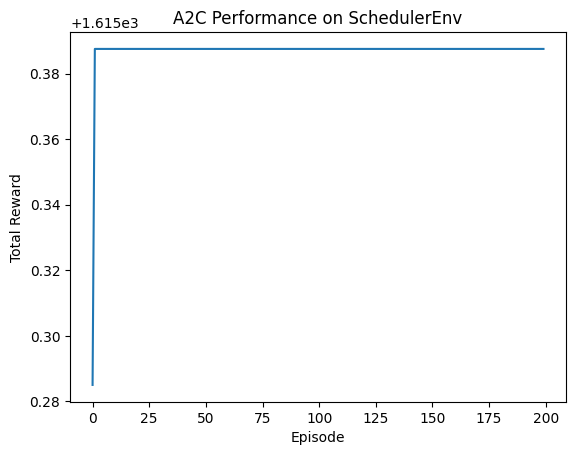

Mean reward over 200 episodes: 1615.39


In [40]:
def evaluate(model, env, num_episodes=20):
    rewards = []
    for ep in range(num_episodes):
        obs, info = env.reset()
        done, truncated = False, False
        total_r = 0
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, truncated, info = env.step(action)
            total_r += r
        rewards.append(total_r)
    return rewards

# Run evaluation
test_env = SchedulerEnvA2C()
ep_rewards = evaluate(model, test_env, num_episodes=200)

# Plot
plt.plot(ep_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("A2C Performance on SchedulerEnv")
plt.show()

print(f"Mean reward over 200 episodes: {np.mean(ep_rewards):.2f}")

In [41]:
from stable_baselines3.common.monitor import Monitor

log_dir = "./a2c_sched_logs"

def make_env(seed=0):
    def _thunk():
        e = SchedulerEnvA2C()
        e = Monitor(e, log_dir)
        e.reset(seed=seed)
        return e
    return _thunk

from stable_baselines3.common.callbacks import BaseCallback

class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []

    def _on_step(self) -> bool:
        # Check if an episode finished
        if self.locals.get("dones") is not None:
            for done, info in zip(self.locals["dones"], self.locals["infos"]):
                if done and "episode" in info:
                    self.episode_rewards.append(info["episode"]["r"])
        return True

reward_logger = RewardLoggerCallback()

model.learn(total_timesteps=200_000, callback=reward_logger)

---------------------------------------
| rollout/              |             |
|    ep_len_mean        | 720         |
|    ep_rew_mean        | 1.96e+03    |
| time/                 |             |
|    fps                | 738         |
|    iterations         | 100         |
|    time_elapsed       | 16          |
|    total_timesteps    | 12000       |
| train/                |             |
|    entropy_loss       | -1.1        |
|    explained_variance | 0.001417458 |
|    learning_rate      | 0.0003      |
|    n_updates          | 265         |
|    policy_loss        | 45          |
|    value_loss         | 1.72e+03    |
---------------------------------------
----------------------------------------
| rollout/              |              |
|    ep_len_mean        | 720          |
|    ep_rew_mean        | 2.24e+03     |
| time/                 |              |
|    fps                | 757          |
|    iterations         | 200          |
|    time_elapsed       | 31     

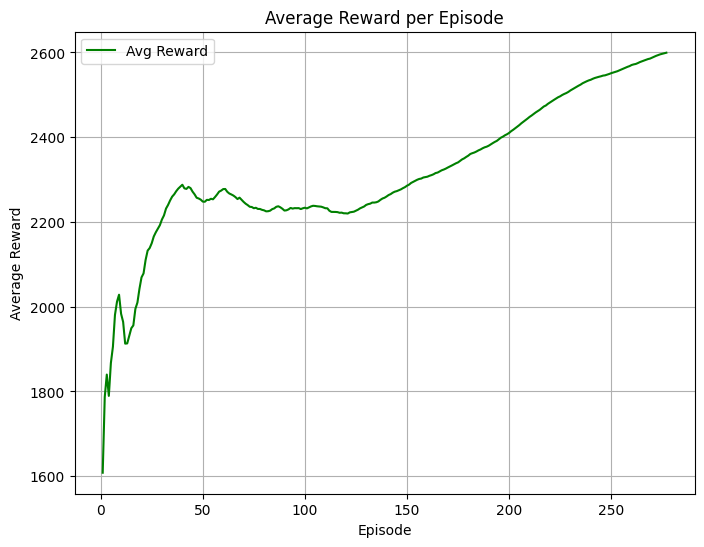

In [46]:
rewards = reward_logger.episode_rewards
episodes = np.arange(1, len(rewards) + 1)

# Compute cumulative average reward
avg_rewards = np.cumsum(rewards) / episodes

plt.figure(figsize=(8,6))
plt.plot(episodes, avg_rewards, color="green", label="Avg Reward")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Average Reward per Episode")
plt.legend()
plt.grid(True)
plt.show()


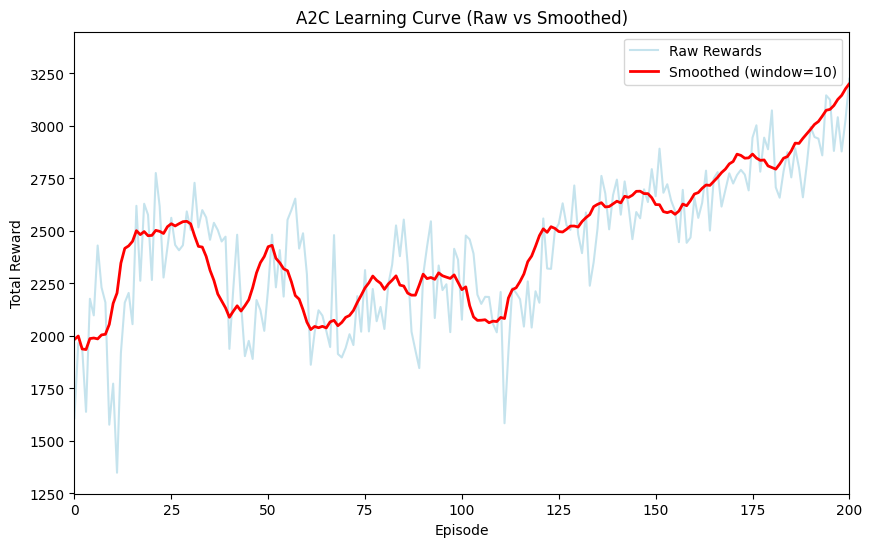

In [47]:
# raw rewards
rewards = reward_logger.episode_rewards

# Simple moving average smoothing
def smooth(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode="valid")

smoothed = smooth(rewards, window=10)

plt.figure(figsize=(10,6))
plt.plot(rewards, color="lightblue", alpha=0.7, label="Raw Rewards")
plt.plot(range(len(smoothed)), smoothed, color="red", linewidth=2, label="Smoothed (window=10)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("A2C Learning Curve (Raw vs Smoothed)")
plt.legend()
plt.xlim(0, 200)
plt.show()


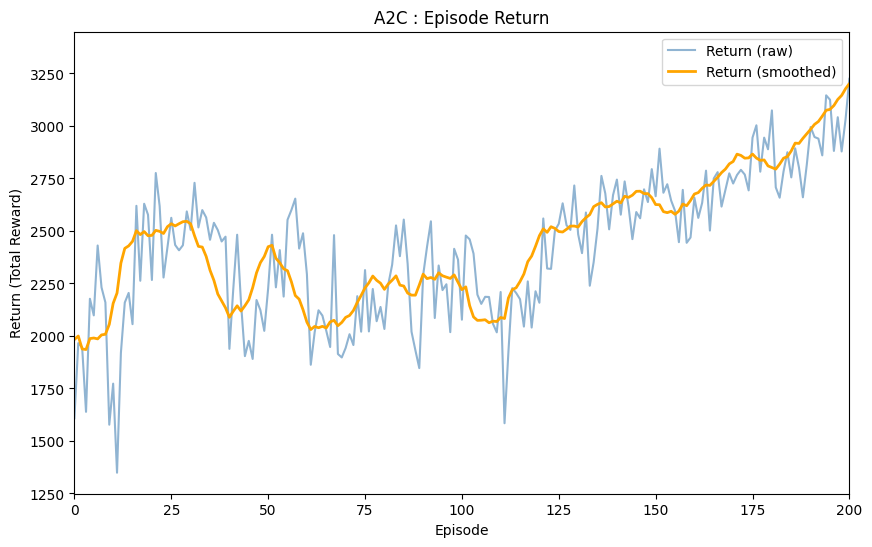

In [48]:
# --- Episode Returns (Raw & Smoothed) ---
episode_returns = reward_logger.episode_rewards  # total reward per episode
episodes = range(len(episode_returns))

def smooth(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode="valid")

smoothed_returns = smooth(episode_returns, window=10)

plt.figure(figsize=(10,6))
plt.plot(episodes, episode_returns, color="steelblue", alpha=0.6, label="Return (raw)")
plt.plot(range(len(smoothed_returns)), smoothed_returns, color="orange", linewidth=2, label="Return (smoothed)")
plt.xlabel("Episode")
plt.ylabel("Return (Total Reward)")
plt.title("A2C : Episode Return")
plt.legend()
plt.xlim(0, 200)
plt.show()


----------------------------------------
| rollout/              |              |
|    ep_len_mean        | 720          |
|    ep_rew_mean        | 2.93e+03     |
| time/                 |              |
|    fps                | 646          |
|    iterations         | 100          |
|    time_elapsed       | 18           |
|    total_timesteps    | 12000        |
| train/                |              |
|    entropy_loss       | -0.625       |
|    explained_variance | 3.284216e-05 |
|    learning_rate      | 0.0003       |
|    n_updates          | 1932         |
|    policy_loss        | 12.2         |
|    value_loss         | 899          |
----------------------------------------
-----------------------------------------
| rollout/              |               |
|    ep_len_mean        | 720           |
|    ep_rew_mean        | 2.96e+03      |
| time/                 |               |
|    fps                | 567           |
|    iterations         | 200           |
|    time

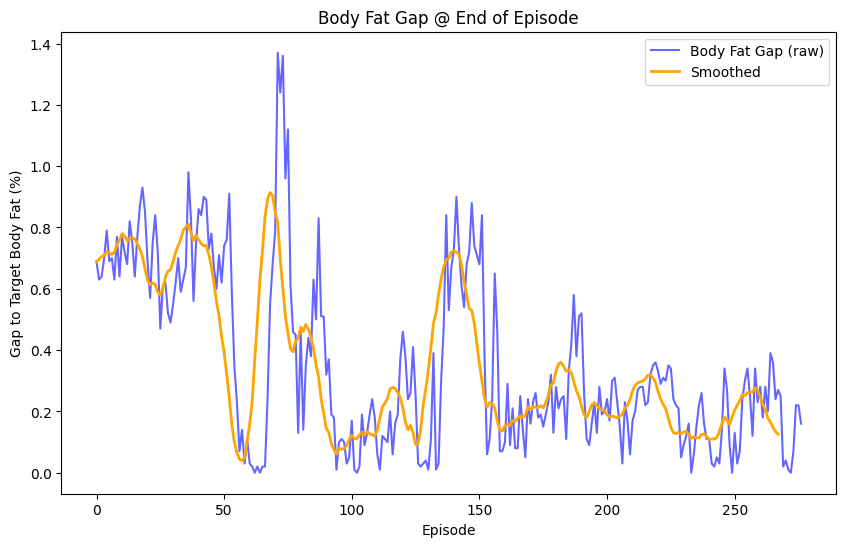

In [49]:
from stable_baselines3.common.callbacks import BaseCallback

class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.body_fat_gaps = []

    def _on_step(self) -> bool:
        if self.locals.get("dones") is not None:
            for done, info in zip(self.locals["dones"], self.locals["infos"]):
                if done and "episode" in info:
                    # log episode reward
                    self.episode_rewards.append(info["episode"]["r"])
                    # log body fat gap if available
                    if "body_fat_gap" in info:
                        self.body_fat_gaps.append(info["body_fat_gap"])
        return True

reward_logger = RewardLoggerCallback()
model.learn(total_timesteps=200_000, callback=reward_logger)

body_fat_gaps = reward_logger.body_fat_gaps
episodes = range(len(body_fat_gaps))

def smooth(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode="valid")

smoothed_gaps = smooth(body_fat_gaps, window=10)

plt.figure(figsize=(10,6))
plt.plot(episodes, body_fat_gaps, color="blue", alpha=0.6, label="Body Fat Gap (raw)")
plt.plot(range(len(smoothed_gaps)), smoothed_gaps, color="orange", linewidth=2, label="Smoothed")
plt.xlabel("Episode")
plt.ylabel("Gap to Target Body Fat (%)")
plt.title("Body Fat Gap @ End of Episode")
plt.legend()
plt.show()

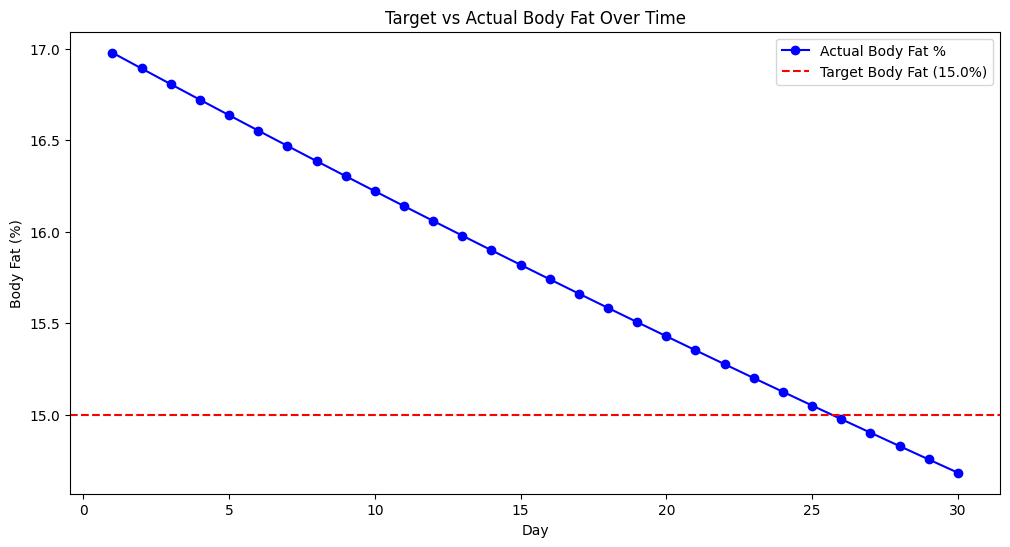

In [50]:
def evaluate_body_fat(model, env, episodes=1):
    """
    Run the trained model in the environment for N episodes
    and log daily body fat values.
    """
    all_days, all_fat = [], []
    day_count = 0
    target = env.target_body_fat

    for ep in range(episodes):
        obs, info = env.reset()
        done, truncated = False, False

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)

            # Log at the END of each day
            if env.state["current_hours"] == env.hours_per_day - 1:
                day_count += 1
                all_days.append(day_count)
                all_fat.append(env.state["current_body_fat"])

    return all_days, all_fat, target


def plot_body_fat(days, fats, target):
    """
    Plot actual body fat vs target body fat line.
    """
    plt.figure(figsize=(12,6))
    plt.plot(days, fats, marker="o", color="blue", label="Actual Body Fat %")
    plt.axhline(y=target, color="red", linestyle="--",
                label=f"Target Body Fat ({target:.1f}%)")
    plt.xlabel("Day")
    plt.ylabel("Body Fat (%)")
    plt.title("Target vs Actual Body Fat Over Time")
    plt.legend()
    plt.show()

env = SchedulerEnvA2C()
days, fats, target = evaluate_body_fat(model, env, episodes=1)
plot_body_fat(days, fats, target)

In [20]:
#Save and reload trained model

model.save("a2c_scheduler_final")
loaded_model = A2C.load("a2c_scheduler_final", env=venv)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


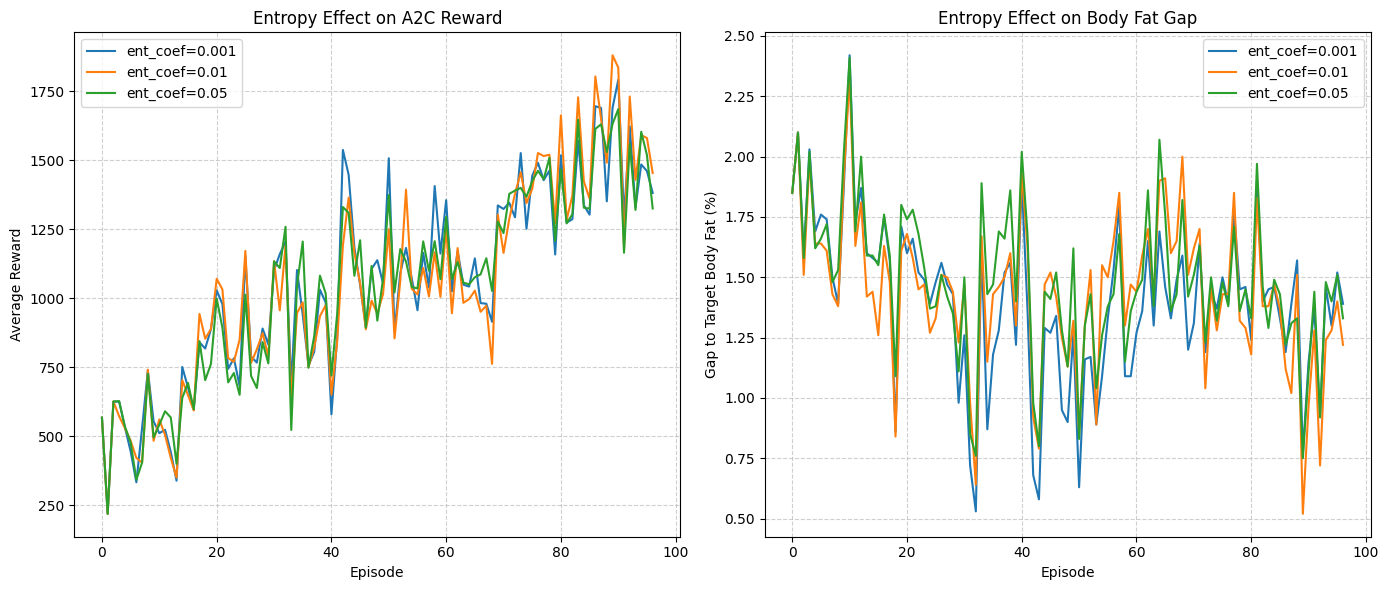

In [51]:
import matplotlib.pyplot as plt
from stable_baselines3.common.callbacks import BaseCallback

def train_with_logging(ent_coef, total_timesteps=50_000, seed=123):

    def make_env():
        env = SchedulerEnvA2C()
        return Monitor(env)

    env = DummyVecEnv([make_env])
    env = VecMonitor(env)

    model = A2C(
        "MultiInputPolicy",
        env,
        learning_rate=3e-4,
        n_steps=5*24,
        gamma=0.99,
        ent_coef=ent_coef,
        verbose=0,
        seed=seed,
        policy_kwargs=dict(net_arch=dict(pi=[128,128], vf=[128,128]))
    )

    class EpisodeLogger(BaseCallback):
        def __init__(self, verbose=0):
            super().__init__(verbose)
            self.episode_rewards = []
            self.body_fat_gaps = []

        def _on_step(self):
            if "infos" in self.locals:
                for info in self.locals["infos"]:
                    if "episode" in info.keys():
                        self.episode_rewards.append(info["episode"]["r"])
                        if "body_fat_gap" in info:
                            self.body_fat_gaps.append(info["body_fat_gap"])
                        else:
                            self.body_fat_gaps.append(None)
            return True

    logger = EpisodeLogger()
    model.learn(total_timesteps=total_timesteps, callback=logger)
    return logger.episode_rewards, logger.body_fat_gaps

entropies = [0.001, 0.01, 0.05]
logs_rewards = {}
logs_bfgaps = {}

for e in entropies:
    rewards, bfgaps = train_with_logging(e, total_timesteps=70_000)
    logs_rewards[e] = rewards
    logs_bfgaps[e] = bfgaps

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True)

for e, rewards in logs_rewards.items():
    axes[0].plot(rewards, label=f"ent_coef={e}")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Average Reward")
axes[0].set_title("Entropy Effect on A2C Reward")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

for e, bfgaps in logs_bfgaps.items():
    axes[1].plot(bfgaps, label=f"ent_coef={e}")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Gap to Target Body Fat (%)")
axes[1].set_title("Entropy Effect on Body Fat Gap")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Test 1: reward=5021.76±0.08, gap=12.37, params={'gender': 0, 'age': 60, 'height': 165.0, 'weight': 70.0, 'target_body_fat': 22.0, 'days_per_episode': 60, 'workloads': 1.5, 'sleep_duration': 8}
Test 2: reward=2961.50±0.06, gap=6.76, params={'gender': 0, 'age': 40, 'height': 185.0, 'weight': 60.0, 'target_body_fat': 16.0, 'days_per_episode': 30, 'workloads': 2.0, 'sleep_duration': 7}
Test 3: reward=943.62±0.09, gap=2.66, params={'gender': 1, 'age': 20, 'height': 172.5, 'weight': 120.0, 'target_body_fat': 30.0, 'days_per_episode': 60, 'workloads': 2.0, 'sleep_duration': 6}
Test 4: reward=2291.38±0.04, gap=0.43, params={'gender': 1, 'age': 30, 'height': 162.2, 'weight': 90.0, 'target_body_fat': 28.0, 'days_per_episode': 30, 'workloads': 1.8, 'sleep_duration': 8}


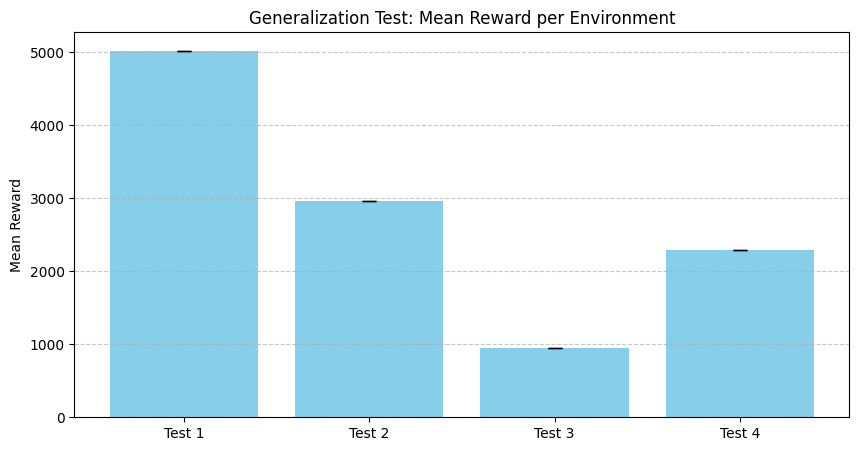

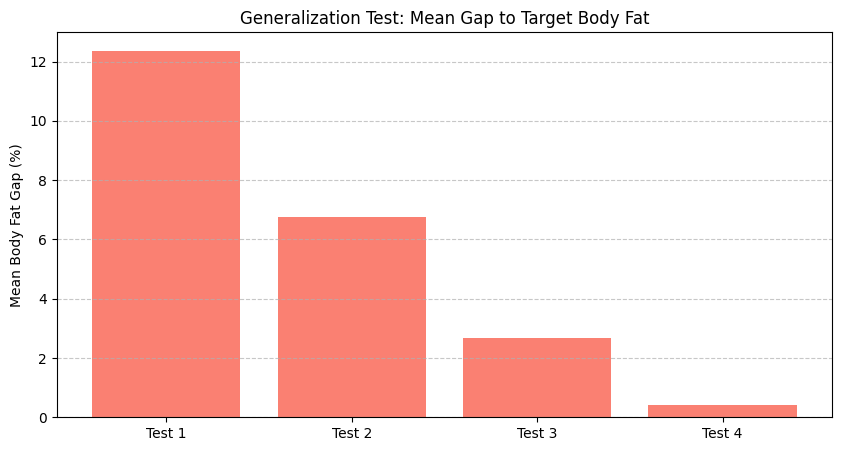

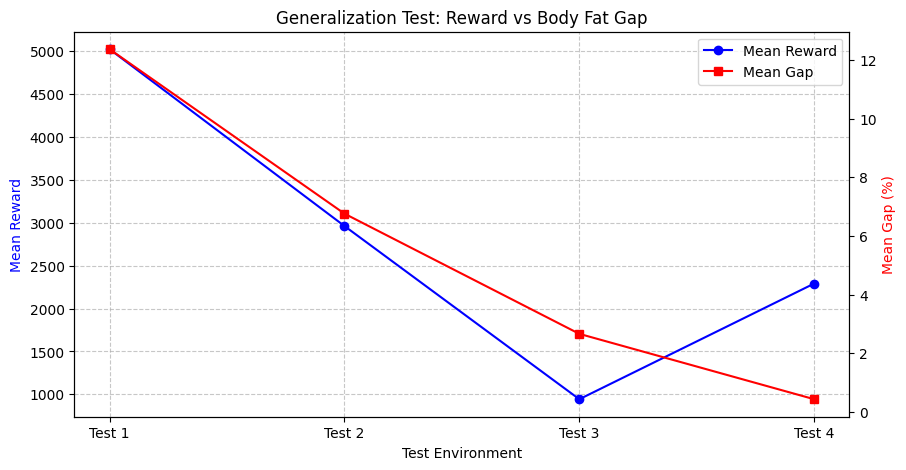

In [52]:
from stable_baselines3.common.env_util import make_vec_env

def evaluate_generalization(model, env_params_list, episodes=10):

    results = {}

    for i, params in enumerate(env_params_list):
        eval_env = SchedulerEnvA2C(**params)
        ep_rewards = []
        ep_gaps = []

        for ep in range(episodes):
            obs, info = eval_env.reset()
            done, truncated = False, False
            ep_reward = 0

            while not (done or truncated):
                action, _ = model.predict(obs, deterministic=True)
                obs, r, done, truncated, info = eval_env.step(action)
                ep_reward += r

            ep_rewards.append(ep_reward)
            ep_gaps.append(info.get("body_fat_gap", np.nan))

        results[f"Test {i+1}"] = {
            "params": params,
            "mean_reward": np.mean(ep_rewards),
            "std_reward": np.std(ep_rewards),
            "mean_gap": np.nanmean(ep_gaps)
        }

        eval_env.close()

    return results

test_envs = [
    {"gender":0, "age":60, "height":165.0, "weight":70.0,
     "target_body_fat":22.0, "days_per_episode":60,
     "workloads":1.5, "sleep_duration":8},

    {"gender":0, "age":40, "height":185.0, "weight":60.0,
     "target_body_fat":16.0, "days_per_episode":30,
     "workloads":2.0, "sleep_duration":7},

    {"gender":1, "age":20, "height":172.5, "weight":120.0,
     "target_body_fat":30.0, "days_per_episode":60,
     "workloads":2.0, "sleep_duration":6},

    {"gender":1, "age":30, "height":162.2, "weight":90.0,
     "target_body_fat":28.0, "days_per_episode":30,
     "workloads":1.8, "sleep_duration":8}
]

gen_results = evaluate_generalization(loaded_model, test_envs, episodes=10)

for k,v in gen_results.items():
    print(f"{k}: reward={v['mean_reward']:.2f}±{v['std_reward']:.2f}, gap={v['mean_gap']:.2f}, params={v['params']}")

labels = list(gen_results.keys())
mean_rewards = [v["mean_reward"] for v in gen_results.values()]
std_rewards = [v["std_reward"] for v in gen_results.values()]
mean_gaps = [v["mean_gap"] for v in gen_results.values()]

plt.figure(figsize=(10,5))
plt.bar(labels, mean_rewards, yerr=std_rewards, capsize=5, color="skyblue")
plt.ylabel("Mean Reward")
plt.title("Generalization Test: Mean Reward per Environment")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(labels, mean_gaps, color="salmon")
plt.ylabel("Mean Body Fat Gap (%)")
plt.title("Generalization Test: Mean Gap to Target Body Fat")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

fig, ax1 = plt.subplots(figsize=(10,5))

ax2 = ax1.twinx()
l1, = ax1.plot(labels, mean_rewards, color="blue", marker="o", label="Mean Reward")
l2, = ax2.plot(labels, mean_gaps, color="red", marker="s", label="Mean Gap")

ax1.set_xlabel("Test Environment")
ax1.set_ylabel("Mean Reward", color="blue")
ax2.set_ylabel("Mean Gap (%)", color="red")

plt.title("Generalization Test: Reward vs Body Fat Gap")
ax1.grid(True, linestyle="--", alpha=0.7)

lines = [l1, l2]
labels = [line.get_label() for line in lines]
plt.legend(lines, labels, loc="upper right")
plt.show()

In [23]:
ACTION_LABELS = {
    0: "skip",
    1: "meal: light",
    2: "meal: balanced",
    3: "meal: heavy",
    4: "snack: high-carb",
    5: "snack: high-protein",
    6: "supplements",
    7: "exercise: light",
    8: "exercise: moderate",
    9: "exercise: intense",
}

ENV_ACTIVITY_LABELS = {
    "sleep": "sleep",
    "work":  "work",
    "walk":  "walk",
    "action":"",
}

def render_one_day(env, model, which_day: int = 0, greedy: bool = True):
    """
    Simulate the policy and print a 24h timeline for which_day (0..days-1).
    Uses the env's scheduler for sleep/work/walk and the agent's chosen action
    during 'action' hours.
    """
    obs, info = env.reset()
    done, truncated = False, False

    # --- Fast-forward to requested day ---
    while env.state["day_of_episode"] < which_day:
        action, _ = model.predict(obs, deterministic=greedy)
        obs, _, done, truncated, info = env.step(action)
        if truncated or done:
            obs, info = env.reset()

    # --- Align to start of day (hour 0) ---
    while env.state["current_hours"] != 0:
        action, _ = model.predict(obs, deterministic=greedy)
        obs, _, done, truncated, info = env.step(action)
        if truncated or done:
            obs, info = env.reset()

    # --- Collect 24h schedule ---
    lines = []
    for _ in range(env.hours_per_day):
        hour = env.state["current_hours"]
        sched = env.scheduler[hour]

        if sched == "action":
            mask = env.get_action_mask()

            action, _ = model.predict(obs, deterministic=greedy)

            if not mask[action]:
                action = 0

            label = ACTION_LABELS.get(int(action), f"action:{int(action)}")
        else:
            action = 0
            label = ENV_ACTIVITY_LABELS.get(sched, sched)

        lines.append(f"{hour:02d}:00 → {label}")
        obs, _, done, truncated, info = env.step(int(action))

    return lines

print("\n=== Day 1 timeline ===")
for line in render_one_day(env, loaded_model, which_day=0, greedy=True):
    print(line)

print("\n=== Day 5 timeline ===")
for line in render_one_day(env, loaded_model, which_day=4, greedy=True):
    print(line)



=== Day 1 timeline ===
00:00 → sleep
01:00 → sleep
02:00 → sleep
03:00 → sleep
04:00 → sleep
05:00 → sleep
06:00 → meal: heavy
07:00 → exercise: intense
08:00 → walk
09:00 → exercise: intense
10:00 → work
11:00 → work
12:00 → meal: balanced
13:00 → work
14:00 → work
15:00 → work
16:00 → work
17:00 → work
18:00 → exercise: moderate
19:00 → exercise: moderate
20:00 → skip
21:00 → skip
22:00 → sleep
23:00 → sleep

=== Day 5 timeline ===
00:00 → sleep
01:00 → sleep
02:00 → sleep
03:00 → sleep
04:00 → sleep
05:00 → sleep
06:00 → meal: heavy
07:00 → exercise: intense
08:00 → walk
09:00 → exercise: intense
10:00 → work
11:00 → work
12:00 → meal: balanced
13:00 → work
14:00 → work
15:00 → work
16:00 → work
17:00 → work
18:00 → exercise: moderate
19:00 → exercise: moderate
20:00 → skip
21:00 → skip
22:00 → sleep
23:00 → sleep


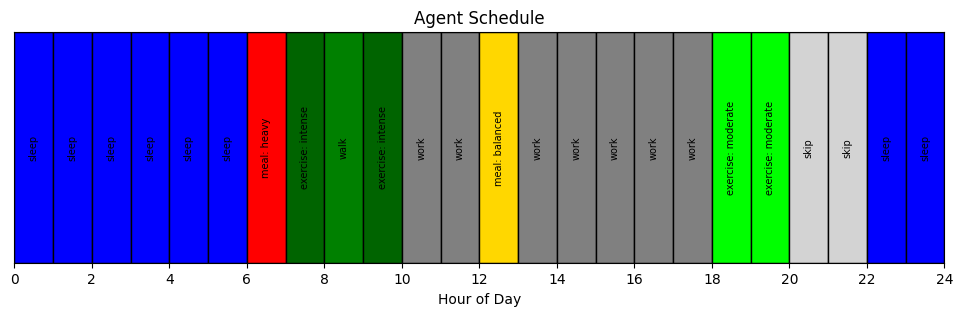

In [53]:
import matplotlib.pyplot as plt

COLOR_MAP = {
    "sleep": "blue",
    "work": "gray",
    "walk": "green",
    "skip": "lightgray",
    "meal: light": "orange",
    "meal: balanced": "gold",
    "meal: heavy": "red",
    "snack: high-carb": "pink",
    "snack: high-protein": "purple",
    "supplements": "brown",
    "exercise: light": "lightgreen",
    "exercise: moderate": "lime",
    "exercise: intense": "darkgreen",
}

def render_one_day_labels(env, model, which_day: int = 0, greedy: bool = True):
    obs, info = env.reset()
    done, truncated = False, False

    while env.state["day_of_episode"] < which_day:
        action, _ = model.predict(obs, deterministic=greedy)
        obs, _, done, truncated, info = env.step(action)
        if truncated or done:
            obs, info = env.reset()

    while env.state["current_hours"] != 0:
        action, _ = model.predict(obs, deterministic=greedy)
        obs, _, done, truncated, info = env.step(action)
        if truncated or done:
            obs, info = env.reset()

    activities = []
    for _ in range(env.hours_per_day):
        hour = env.state["current_hours"]
        sched = env.scheduler[hour]

        if sched == "action":
            mask = env.get_action_mask()
            action, _ = model.predict(obs, deterministic=greedy)
            if not mask[action]:
                action = 0
            label = ACTION_LABELS.get(int(action), f"action:{int(action)}")
        else:
            action = 0
            label = ENV_ACTIVITY_LABELS.get(sched, sched)

        activities.append((hour, label))
        obs, _, done, truncated, info = env.step(int(action))

    return activities

def plot_schedule(activities, title="Agent Schedule"):
    fig, ax = plt.subplots(figsize=(12, 3))

    for hour, label in activities:
        ax.broken_barh([(hour, 1)], (0, 5),
                       facecolors=COLOR_MAP.get(label, "lightgray"),
                       edgecolors="black")
        ax.text(hour + 0.5, 2.5, label, ha="center", va="center", fontsize=7, rotation=90)

    ax.set_xlim(0, 24)
    ax.set_ylim(0, 5)
    ax.set_xticks(range(0, 25, 2))
    ax.set_yticks([])
    ax.set_xlabel("Hour of Day")
    ax.set_title(title)
    plt.show()

activities_day1 = render_one_day_labels(env, loaded_model, which_day=0, greedy=True)
plot_schedule(activities_day1, title="Agent Schedule")